In [1]:
!git clone https://huggingface.co/ctheodoris/Geneformer; cd Geneformer; pip install .

Cloning into 'Geneformer'...
remote: Enumerating objects: 1082, done.
remote: Counting objects: 100% (124/124), done.
remote: Compressing objects: 100% (124/124), done.
remote: Total 1082 (delta 65), reused 0 (delta 0), pack-reused 958 (from 1)
Receiving objects: 100% (1082/1082), 5.74 MiB | 10.54 MiB/s, done.
Resolving deltas: 100% (675/675), done.
Filtering content: 100% (27/27), 1.47 GiB | 41.42 MiB/s, done.
Processing /content/Geneformer
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.6/49.6 kB 3.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.5/144.5 kB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 386.6/386.6 kB 27.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.5/98.5 

In [2]:
!pip install anndata scanpy transformers datasets torch h5py cellxgene_census mygene

INFO: pip is looking at multiple versions of s3fs to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 47.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.9/78.9 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.3/13.3 MB 50.9 MB/s eta 0:00:00


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import pandas as pd
import numpy as np
import scanpy as sc
import os
import json
from tqdm import tqdm
import matplotlib.pyplot as plt
import random
import re
import os
import scipy.sparse
from anndata import AnnData
import gc
import h5py
import scipy.sparse as sparse
from scipy.sparse import csr_matrix, vstack
import anndata as ad
import anndata
import torch
from datasets import Dataset, load_from_disk
from geneformer import TranscriptomeTokenizer

In [5]:
# Parse the metadata text from the ontologies
def parse_cell_ontology(file_path):
    with open(file_path, 'r', encoding='utf-8') as f:
        data = json.load(f)

    def extract_info(cell_id, entry):
        """ Extracts relevant fields while handling nested structures. """
        return {
            "id": cell_id,  # Extract the outer dictionary key as the ID
            "name": entry.get("name", ""),
            "definition": entry.get("def", ""),
            "synonyms": entry.get("synonym", []) if isinstance(entry.get("synonym"), list) else [entry.get("synonym")] if entry.get("synonym") else [],
        }

    parsed_data = [extract_info(cell_id, details) for cell_id, details in data.items()]

    return parsed_data

In [6]:
def tokenize_with_geneformer(input_dir, output_dir, dataset_name):
    """
    Tokenize an h5ad file using Geneformer's TranscriptomeTokenizer and save as an Arrow file.

    Parameters:
    -----------
    h5ad_path : str
        Path to the input .h5ad file.
    output_dir : str
        Directory to save the tokenized dataset.
    dataset_name : str
        Name of the dataset.

    Returns:
    --------
    str
        Path to the saved tokenized dataset.
    """
    # Default custom attributes
    custom_attrs = {
        "soma_joinid": "soma_joinid",
        "cell_type": "cell_type",
        "cell_type_ontology_term_id": "cell_type_ontology_term_id",
        "development_stage": "development_stage",
        "disease": "disease",
        "disease_ontology_term_id": "disease_ontology_term_id",
        "sex": "sex",
        "tissue": "tissue",
        "tissue_ontology_term_id": "tissue_ontology_term_id",
        "tissue_general": "tissue_general",
        "tissue_general_ontology_term_id": "tissue_general_ontology_term_id",
    }

    # Ensure output directory exists
    os.makedirs(output_dir, exist_ok=True)

    # Initialize Tokenizer
    tk = TranscriptomeTokenizer(custom_attrs)

    # Tokenize the data
    tk.tokenize_data(
        input_dir,
        output_dir,
        dataset_name,
        file_format="h5ad"
    )


In [7]:
def add_struct_description(dataset: Dataset, ontology_dict: dict, batch_size: int = 1000) -> Dataset:
    """Add a structured text description column to a Hugging Face dataset based on ontology info and top genes."""

    # Identify all ontology columns
    ontology_columns = [col for col in dataset.column_names if col.endswith('_ontology_term_id')]
    base_columns = {col: col.replace('_ontology_term_id', '') for col in ontology_columns}

    # Function to process batches
    def process_batch(examples):
        batch_descriptions = []
        batch_size_actual = len(examples[list(examples.keys())[0]])  # Get actual batch size

        for i in range(batch_size_actual):
            cell_desc_parts = []

            # Get values for this example
            example = {key: values[i] for key, values in examples.items()}

            # Handle ontology-based description
            for onto_col, base_col in base_columns.items():
                ontology_id = str(example.get(onto_col, '')).upper() if example.get(onto_col) else ""
                base_value = example.get(base_col, '')

                if not ontology_id:
                    continue

                definition = ""
                if ontology_id in ontology_dict:
                    definition = ontology_dict[ontology_id].get('definition', '')

                if base_value and definition:
                    desc_part = f"{base_col.replace('_', ' ').title()}: {base_value}, {definition}"
                    cell_desc_parts.append(desc_part)
                elif base_value:
                    desc_part = f"{base_col.replace('_', ' ').title()}: {base_value}"
                    cell_desc_parts.append(desc_part)


            # For age
            age = example.get("development_stage", "")
            if age and age.lower() != 'unknown':
                cell_desc_parts.append(f"Development Stage: {age}")

            # For sex
            sex = example.get("sex", "")
            if sex and sex.lower() != 'unknown':
                cell_desc_parts.append(f"Sex: {sex}")

            # Construct the final structured description
            struct_desc = "; ".join(cell_desc_parts) + "." if cell_desc_parts else ""
            batch_descriptions.append(struct_desc)

        examples["struct_desc"] = batch_descriptions
        return examples

    # Apply function to entire dataset with explicit batching
    print("Adding structured descriptions to all examples...")
    return dataset.map(
        process_batch,
        batched=True,
        batch_size=batch_size,
        desc="Adding structured descriptions"
    )

In [8]:
def process_dataset(
    input_dir="/content/drive/MyDrive/cell2text_dataset",
    output_dir="/content/drive/MyDrive/cell2text_dataset_final",
    dataset_name="final_dataset",
    ontology_filepath="/content/drive/MyDrive/obo.json",
    batch_size=1000  # Add batch_size parameter
):
    print("Tokenizing dataset...")

    #Tokenize the dataset
    tokenize_with_geneformer(input_dir, output_dir, dataset_name)

    print("Loading tokenized dataset...")
    # Load the tokenized dataset
    hf_dataset = load_from_disk("/content/drive/MyDrive/cell2text_dataset_final/final_dataset.dataset")

    print(f"Dataset info: {hf_dataset}")
    print(f"Columns: {hf_dataset.column_names}")
    print(f"Shape: {hf_dataset.shape}")
    print(f"Total number of examples: {len(hf_dataset)}")



    print("Adding structured descriptions...")
    #Load ontology dictionary
    parsed_cells = parse_cell_ontology(ontology_filepath)
    ontology_dict = {
        cell["id"]: {
            "name": cell["name"],
            "definition": cell["definition"],
            "synonym": cell["synonyms"]
        }
        for cell in parsed_cells
    }

    #Add structured descriptions
    hf_dataset = add_struct_description(hf_dataset, ontology_dict, batch_size=batch_size)

    # Verify all examples have descriptions
    print(f"Examples with struct_desc: {sum(1 for ex in hf_dataset if 'struct_desc' in ex and ex['struct_desc'])}")

    print("Saving final dataset...")
    #Save the final dataset
    final_save_path = os.path.join(output_dir, dataset_name + "_with_descriptions")
    hf_dataset.save_to_disk(final_save_path)
    print(f"Final dataset saved to {final_save_path}")
    print(f"Final dataset size: {len(hf_dataset)} examples")

    return hf_dataset

In [9]:
hf_dataset = process_dataset()

Tokenizing dataset...
Tokenizing /content/drive/MyDrive/cell2text_dataset/batch_0.h5ad


100%|██████████| 4/4 [00:09<00:00,  2.42s/it]
/usr/local/lib/python3.11/dist-packages/anndata/_core/merge.py:1434: UserWarning: Only some AnnData objects have `.raw` attribute, not concatenating `.raw` attributes.
  warn(
/usr/local/lib/python3.11/dist-packages/anndata/_core/anndata.py:787: ImplicitModificationWarning: Trying to modify index of attribute `.obs` of view, initializing view as actual.
  getattr(self, attr).index = value
/usr/local/lib/python3.11/dist-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/usr/local/lib/python3.11/dist-packages/geneformer/tokenizer.py:495: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  for i in adata.var["ensembl_id_collapsed"][coding_miRNA

/content/drive/MyDrive/cell2text_dataset/batch_0.h5ad has no column attribute 'filter_pass'; tokenizing all cells.
Tokenizing /content/drive/MyDrive/cell2text_dataset/batch_2000.h5ad


100%|██████████| 4/4 [00:08<00:00,  2.18s/it]
/usr/local/lib/python3.11/dist-packages/anndata/_core/merge.py:1434: UserWarning: Only some AnnData objects have `.raw` attribute, not concatenating `.raw` attributes.
  warn(
/usr/local/lib/python3.11/dist-packages/anndata/_core/anndata.py:787: ImplicitModificationWarning: Trying to modify index of attribute `.obs` of view, initializing view as actual.
  getattr(self, attr).index = value
/usr/local/lib/python3.11/dist-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/usr/local/lib/python3.11/dist-packages/geneformer/tokenizer.py:495: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  for i in adata.var["ensembl_id_collapsed"][coding_miRNA

/content/drive/MyDrive/cell2text_dataset/batch_2000.h5ad has no column attribute 'filter_pass'; tokenizing all cells.
Tokenizing /content/drive/MyDrive/cell2text_dataset/batch_4000.h5ad


...

/content/drive/MyDrive/cell2text_dataset/batch_96000.h5ad has no column attribute 'filter_pass'; tokenizing all cells.
Tokenizing /content/drive/MyDrive/cell2text_dataset/batch_98000.h5ad


100%|██████████| 4/4 [00:11<00:00,  2.92s/it]
/usr/local/lib/python3.11/dist-packages/anndata/_core/merge.py:1434: UserWarning: Only some AnnData objects have `.raw` attribute, not concatenating `.raw` attributes.
  warn(
/usr/local/lib/python3.11/dist-packages/anndata/_core/anndata.py:787: ImplicitModificationWarning: Trying to modify index of attribute `.obs` of view, initializing view as actual.
  getattr(self, attr).index = value
/usr/local/lib/python3.11/dist-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/usr/local/lib/python3.11/dist-packages/geneformer/tokenizer.py:495: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  for i in adata.var["ensembl_id_collapsed"][coding_miRNA

/content/drive/MyDrive/cell2text_dataset/batch_98000.h5ad has no column attribute 'filter_pass'; tokenizing all cells.
Creating dataset.
Loading tokenized dataset...


/usr/local/lib/python3.11/dist-packages/datasets/table.py:1421: FutureWarning: promote has been superseded by promote_options='default'.
  table = cls._concat_blocks(blocks, axis=0)


Dataset info: Dataset({
    features: ['input_ids', 'soma_joinid', 'cell_type', 'cell_type_ontology_term_id', 'development_stage', 'disease', 'disease_ontology_term_id', 'sex', 'tissue', 'tissue_ontology_term_id', 'tissue_general', 'tissue_general_ontology_term_id', 'length'],
    num_rows: 99999
})
Columns: ['input_ids', 'soma_joinid', 'cell_type', 'cell_type_ontology_term_id', 'development_stage', 'disease', 'disease_ontology_term_id', 'sex', 'tissue', 'tissue_ontology_term_id', 'tissue_general', 'tissue_general_ontology_term_id', 'length']
Shape: (99999, 13)
Total number of examples: 99999
Adding structured descriptions...
Adding structured descriptions to all examples...
Examples with struct_desc: 99999
Saving final dataset...
Final dataset saved to /content/drive/MyDrive/cell2text_dataset_final/final_dataset_with_descriptions
Final dataset size: 99999 examples


In [10]:
print(hf_dataset[42])

{'input_ids': [2, 3491, 11581, 2266, 4306, 10584, 14257, 14111, 10514, 10423, 19560, 15216, 1004, 13466, 10524, 12812, 3483, 15036, 17107, 10655, 7336, 11264, 11799, 9484, 17464, 3880, 9850, 4530, 14239, 5866, 16490, 9548, 6502, 10867, 8500, 10122, 6537, 7343, 18430, 6142, 13266, 1710, 2930, 13568, 11992, 3755, 10369, 16595, 12947, 19222, 213, 17183, 13575, 8090, 9275, 5796, 598, 4665, 6174, 2655, 8883, 8760, 367, 16401, 8812, 17817, 18343, 5659, 7365, 8510, 1523, 4263, 850, 3054, 8003, 17045, 14952, 15025, 16097, 4979, 796, 12602, 10119, 10506, 4704, 7255, 6732, 16647, 16642, 14775, 5475, 3785, 15478, 4527, 424, 494, 13603, 7226, 10407, 6645, 13255, 10647, 3790, 3891, 8943, 11750, 2355, 1547, 1019, 12208, 2098, 14123, 9716, 17970, 2735, 9250, 4923, 6927, 374, 1756, 3715, 3856, 988, 10994, 1031, 5744, 13785, 3704, 2987, 4953, 8378, 14311, 14653, 4485, 6327, 11279, 2410, 3730, 17567, 9968, 17545, 12413, 9695, 3566, 15184, 15550, 9667, 2462, 11345, 4244, 7846, 7508, 12288, 14956, 3273, 1

In [11]:
import matplotlib.pyplot as plt
import numpy as np

def plot_length_histogram(hf_dataset):
    """
    Plots a histogram of the 'length' column from a Hugging Face dataset,
    assuming 'length' is directly available.

    Args:
        hf_dataset (datasets.Dataset): The Hugging Face dataset containing
                                       a 'length' column.
    """
    if "length" not in hf_dataset.column_names:
        print("Error: The dataset does not contain a 'length' column.")
        print("Available columns:", hf_dataset.column_names)
        return

    print(f"Extracting 'length' column from {len(hf_dataset)} examples...")
    # Extract the 'length' column. Hugging Face datasets are efficient for this.
    lengths = hf_dataset["length"]

    # Convert to a NumPy array for plotting
    lengths_array = np.array(lengths)

    plt.figure(figsize=(12, 7))
    # Determine a reasonable number of bins. You might want to adjust this.
    # A common approach is sqrt(number of data points) or a fixed number like 50.
    num_bins = min(50, int(np.sqrt(len(lengths_array)))) # Adjust bins dynamically
    plt.hist(lengths_array, bins=num_bins, edgecolor='black', alpha=0.8, color='#6A5ACD')
    plt.title('Distribution of Tokenized Sequence Lengths', fontsize=16)
    plt.xlabel('Sequence Length', fontsize=14)
    plt.ylabel('Frequency', fontsize=14)
    plt.grid(axis='y', alpha=0.7)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    plt.tight_layout() # Adjust layout to prevent labels from overlapping
    plt.show()

Extracting 'length' column from 99999 examples...


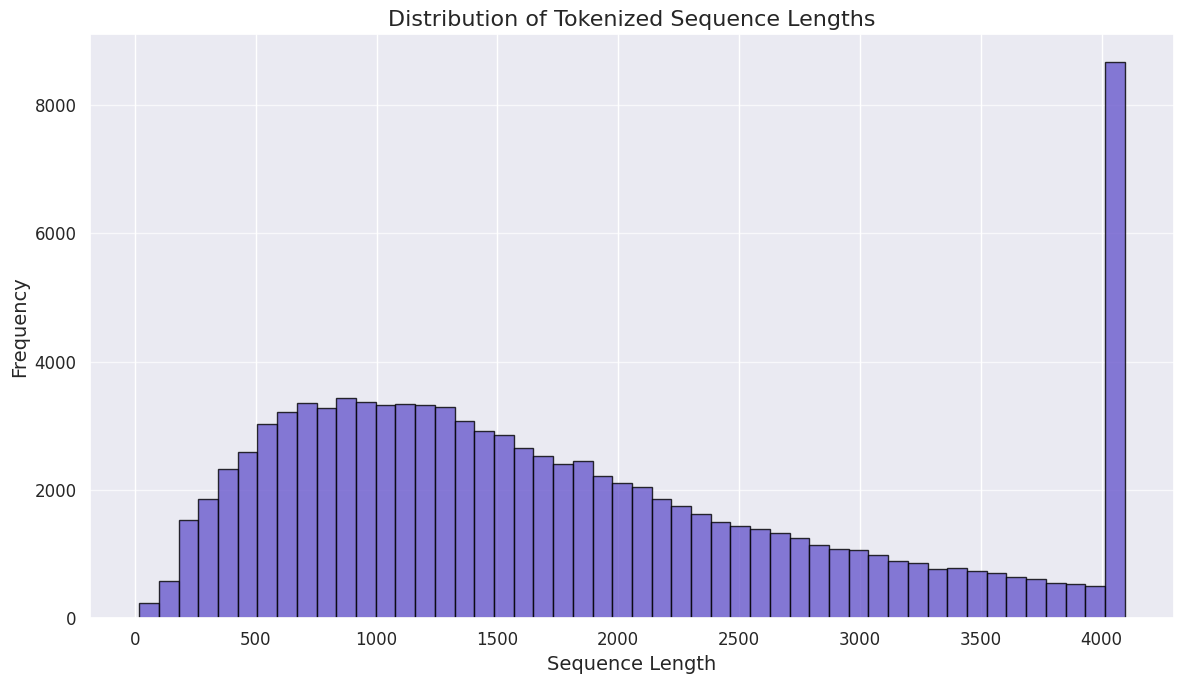

In [13]:
 plot_length_histogram(hf_dataset)